**NOTE**
i have built upon the lecture code. the homework exercise 1 is at the end. I cut out all the lecture code that is not necessary for the exercise code to run (mainly the plotting code from the lecture). my apologies for the slight mess that is the remainder of the lecture code

In [9]:
import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from tqdm import tqdm
import seaborn as sns
import pickle
import sys
import os
sys.path.insert(0, r'C:\Users\mqsim\neuroanalysis\code')
sys.path.append(os.path.abspath("code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

In [3]:
# Download lesson data
download_data('https://surfdrive.surf.nl/files/index.php/s/z7mMiznEWOT0Iak')

**Import and unpack the data**

In [10]:
#import data
with open('data/psth_data.pickle', 'rb') as handle:
    data = pickle.load(handle)

spike_times = data['spike_times']
stim_onsets = data['stim_onsets']
stim_type = data['stim_type']
stim_duration = data['stim_duration']

C:\Users\mqsim\AppData\Local\Temp\ipykernel_27952\1997105126.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(handle)


**Set time window around stimulus presentation and align spike times with stimulus onset for both stimuli**

In [11]:
# cut and align to stimulus presentation
psth_onset = -0.5
psth_offset = stim_duration+0.5


aligned_spikes_stim1 = []
stim1_onsets = stim_onsets[stim_type==1]

for cell_spikes in spike_times:
    aligned_spikes = []
    for stim_onset in stim1_onsets:
        onset = stim_onset + psth_onset
        offset = stim_onset +psth_offset
        # take only spikes before, during and after stimulus, aligned to stimulus onset
        stim_spikes = [spike-stim_onset for spike in cell_spikes if (spike>=onset and spike<offset)]
        aligned_spikes.append(stim_spikes)

    aligned_spikes_stim1.append(aligned_spikes)

aligned_spikes_stim2 = []
stim1_onsets = stim_onsets[stim_type==2]

for cell_spikes in spike_times:
    aligned_spikes = []
    for stim_onset in stim1_onsets:
        onset = stim_onset + psth_onset
        offset = stim_onset +psth_offset
        # take only spikes during stimulus, aligned to stimulus onset
        stim_spikes = [spike-stim_onset for spike in cell_spikes if (spike>=onset and spike<offset)]
        aligned_spikes.append(stim_spikes)

    aligned_spikes_stim2.append(aligned_spikes)
        

**Simulating place cell activity**

In [12]:
track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution

**Create true firing rates per bin for each place cell**

In [13]:
bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

**Simulate the trajectory of the mouse**

In [14]:
n_runs = 20 
av_running_speed = 10 # the average running speed (in cm/s)
fps = 30 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])
for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    x = np.concatenate((x, stop1, run1, stop2, run2))
t = np.arange(len(x))/fps

In [15]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = 0.1 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):
    # create instantenous firing rate for each neuron i
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    # Generate the location of the spikes
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    # Find indices of time bins where spikes occur
    sp = np.argwhere(spikes_loc)
    # Find actual time in ms of time bins where spikes occur
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:28<00:00,  1.12it/s]


**Realign spikes and their position**

In [17]:
spike_positions = [np.interp(s, t, x) for s in spikes]

### **Homework**

### **Exercise 1A**

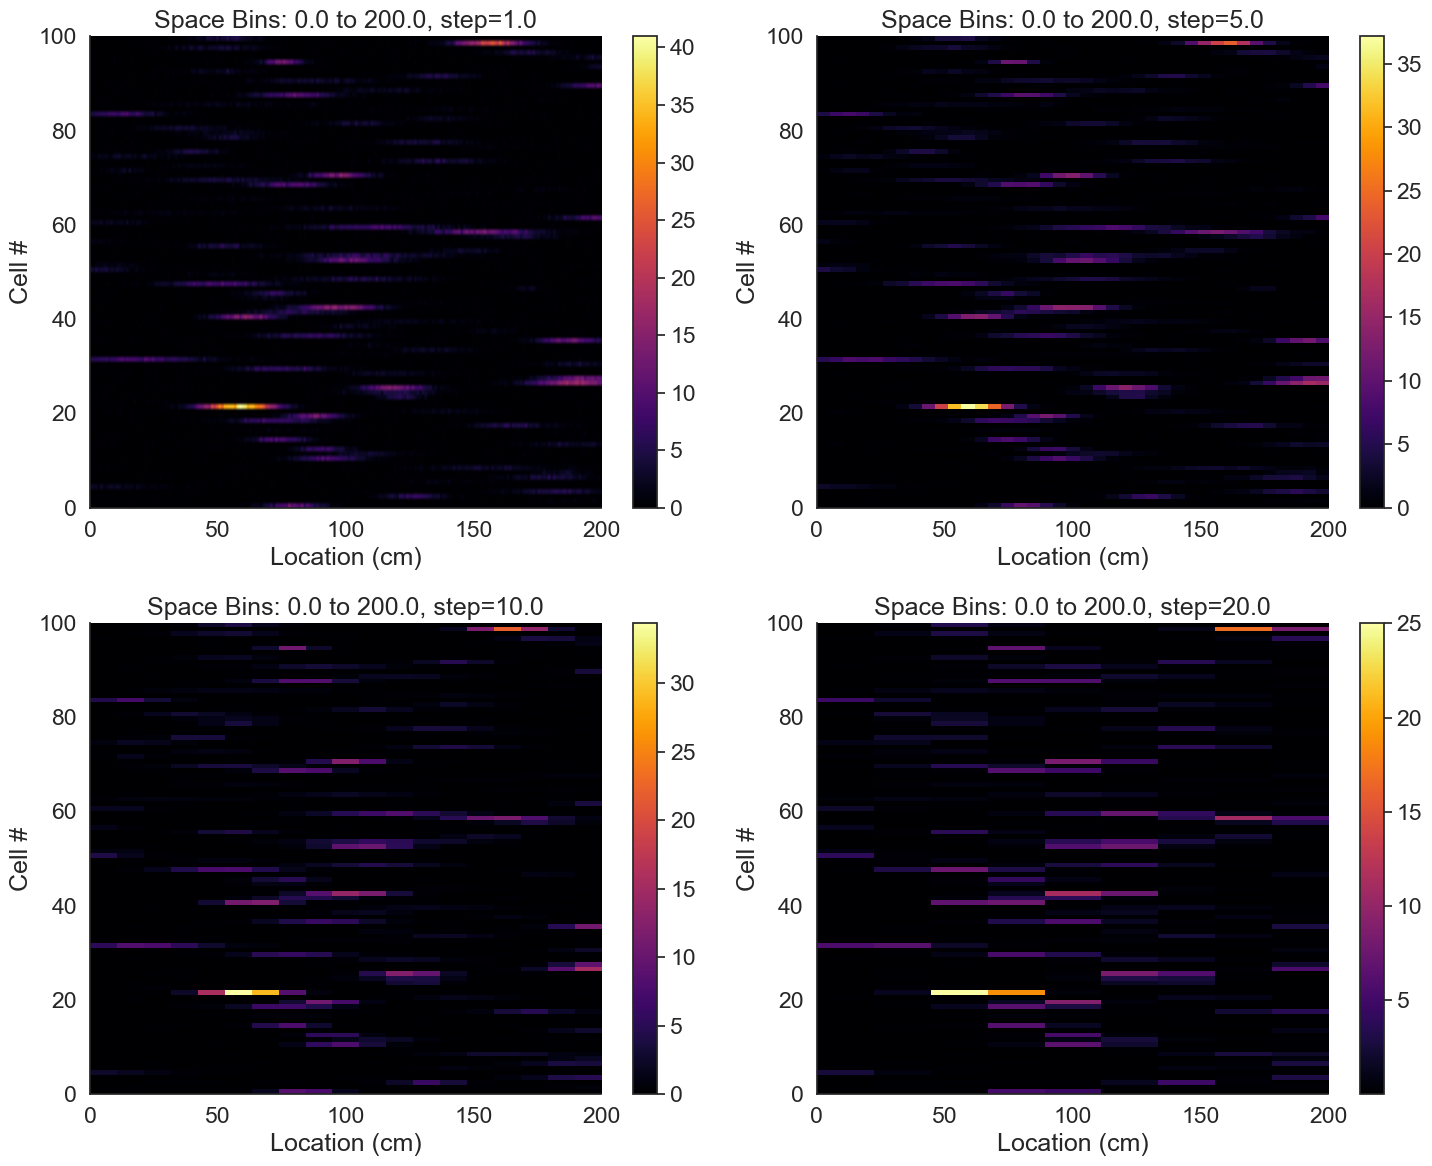

In [18]:
# Create a list of different space binnings
space_bins_list = [
    np.arange(0., 200., 1.),
    np.arange(0., 200., 5.),
    np.arange(0., 200., 10.),
    np.arange(0., 200., 20.)
]

# Initialize plot with 4 subplots 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()  # Flatten for easy iteration

for i, space_bins in enumerate(space_bins_list):
    # we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
    # put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)

    # we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps

    firing_rate_map = spikes_hist / occupancy 

    im = axes[i].imshow(firing_rate_map, cmap='inferno', extent=[0, 200, 0, n_cells], aspect='auto')
    axes[i].set_title(f"Space Bins: {space_bins[0]} to {space_bins[-1] + space_bins[1]}, step={space_bins[1]}")
    axes[i].set_xlabel('Location (cm)')
    axes[i].set_ylabel('Cell #')
    fig.colorbar(im, ax=axes[i])  # Add a colorbar to each subplot firing rate

plt.tight_layout()
plt.show()

**Comment Exercise 1A**
The code is essentially the same as the lecture code, but it iterates through four values of bin size, resulting in four subplots with each a unique bin size value.
Subplot 1 represents a coarser binning, subplot 2 the intiial binning size and subplot 3 and 4 have increasing broader bins. Comparing subplot 1 and 2, a coarser binning results in a more detailed firing rate map, where each streak caused by higher firing rates seem more fine-grained, giving a more accurate description of each neuron's firing behaviour against location on the track. Conversely, looking at subplot 3 and 4 against 2, increasing the bin sizes results in less detailed firing rates against location, which is evident from the firing rate streaks consisting of less "blocks" for each neuron in subplot 3 compared to subplot 2 (which is even more clear in subplot 4). Increasing the binsizes results in the data being represented less accurately with less detail.

### **Exercise 1B**

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:28<00:00,  1.13it/s]


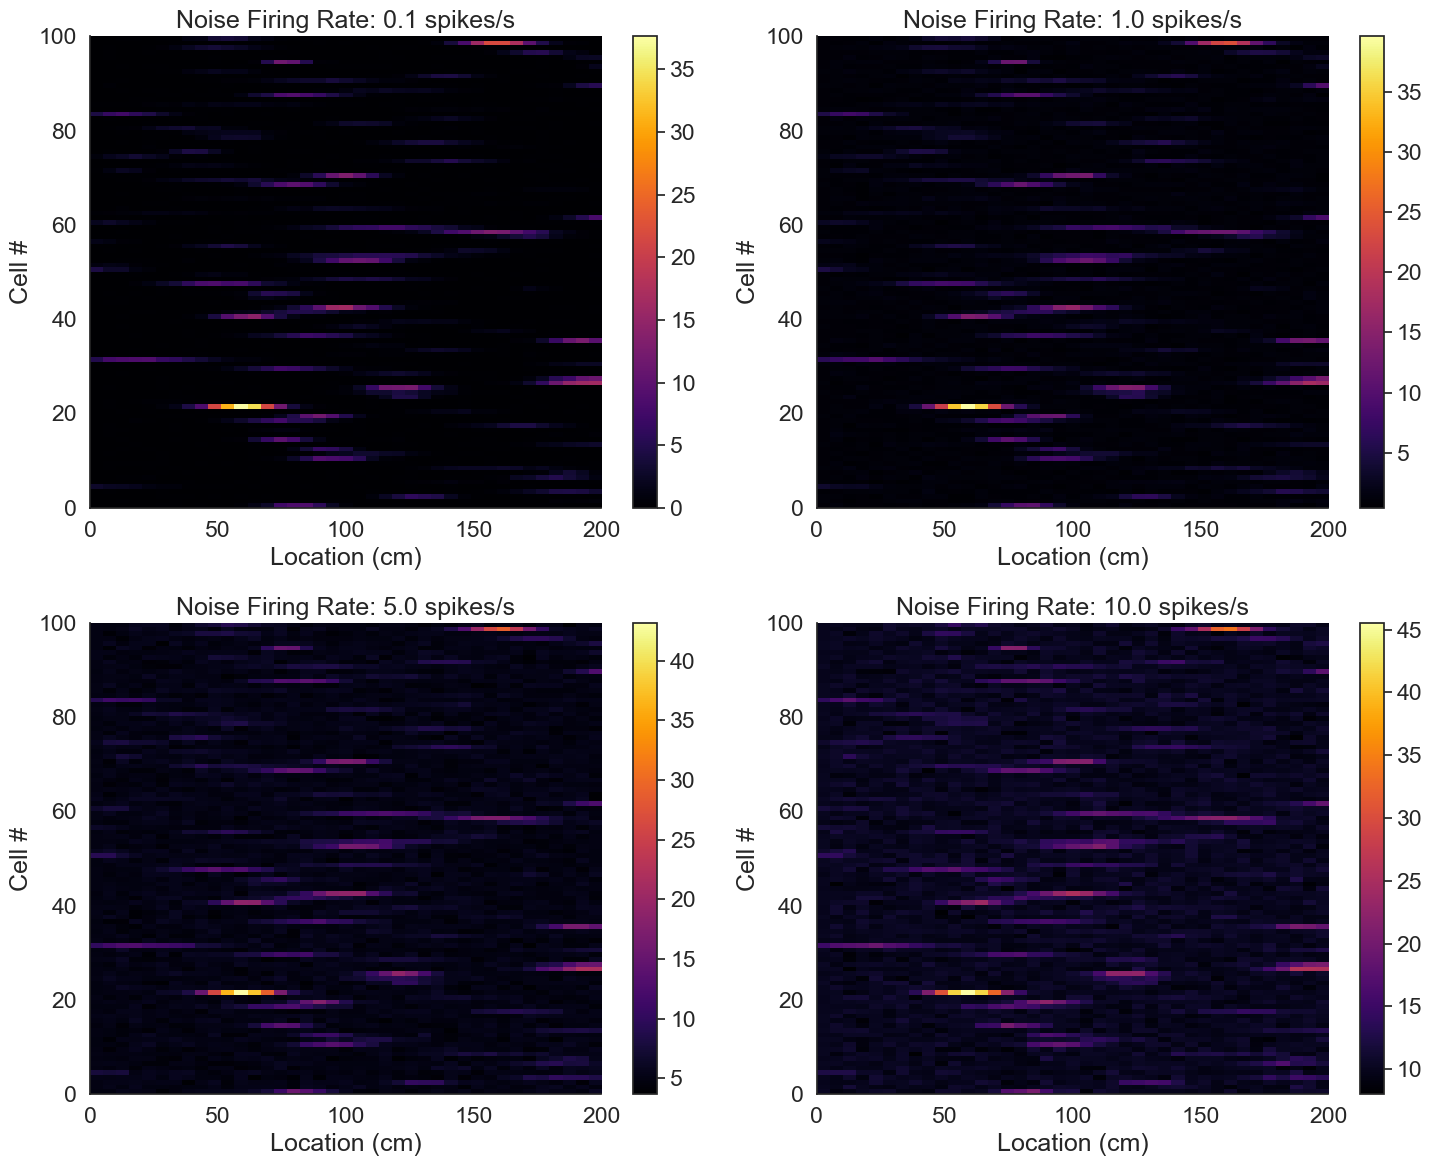

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Define noise levels to test
noise_values = [0.1, 1.0, 5.0, 10.0]  # Adjust as needed

# Fixed spatial binning: 0-200 in steps of 5
space_bins = np.arange(0., 200., 5.)

# Initialize a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for j, noise_firing_rate in enumerate(noise_values):
    # Simulate spikes for this noise level
    spikes = []
    t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
    x_sampling = np.floor(np.interp(t_sampling, t, x))

    for i in tqdm(range(n_cells)):
        # create instantenous firing rate for each neuron i
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        # Generate the location of the spikes
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        # Find indices of time bins where spikes occur
        sp = np.argwhere(spikes_loc)
        # Find actual time in ms of time bins where spikes occur
        t_sp = t_sampling[sp]
        spikes.append(t_sp)

    # Convert spike times to positions (assuming `x` is aligned with `t`)
    spike_positions = [np.interp(spike_times, t, x) for spike_times in spikes]

    # Compute histograms for each cell
    spikes_hist = [np.histogram(s, space_bins)[0] for s in spike_positions]
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)
    
    # we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps

    firing_rate_map = spikes_hist / occupancy 

    #Plot
    im = axes[j].imshow(firing_rate_map, cmap = 'inferno', extent = [0, 200, 0, n_cells], aspect = 'auto')
    axes[j].set_title(f"Noise Firing Rate: {noise_firing_rate} spikes/s")
    axes[j].set_xlabel('Location (cm)')
    axes[j].set_ylabel('Cell #')
    fig.colorbar(im, ax=axes[j])

plt.tight_layout()
plt.show()

**Comment Exercise 1B**
The variable noise_firing_rate determines the noise level in the initial code. I have made a list containing noise values and iterate them through code to create a 2x2 plot, each subplot having a different noise value. It is quite similar to the code i used in exercise 1A, but now the bin size is again constant at 5.0. Evident from the subplots, increasing the noise value results in more "activity" for each neuron, as more faint spots can be seen at locations where the neuron does not fire. This is ofcourse no activity/firing rate of the neruon itself, but noise. In short, if noise_value increases, the firing rate maps will become less place-specific. If noise is prominent in data, getting more data improves the signal-to-noise ratio or apply a threshold.

### **Exercise 1C**

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:23<00:00,  1.20it/s]


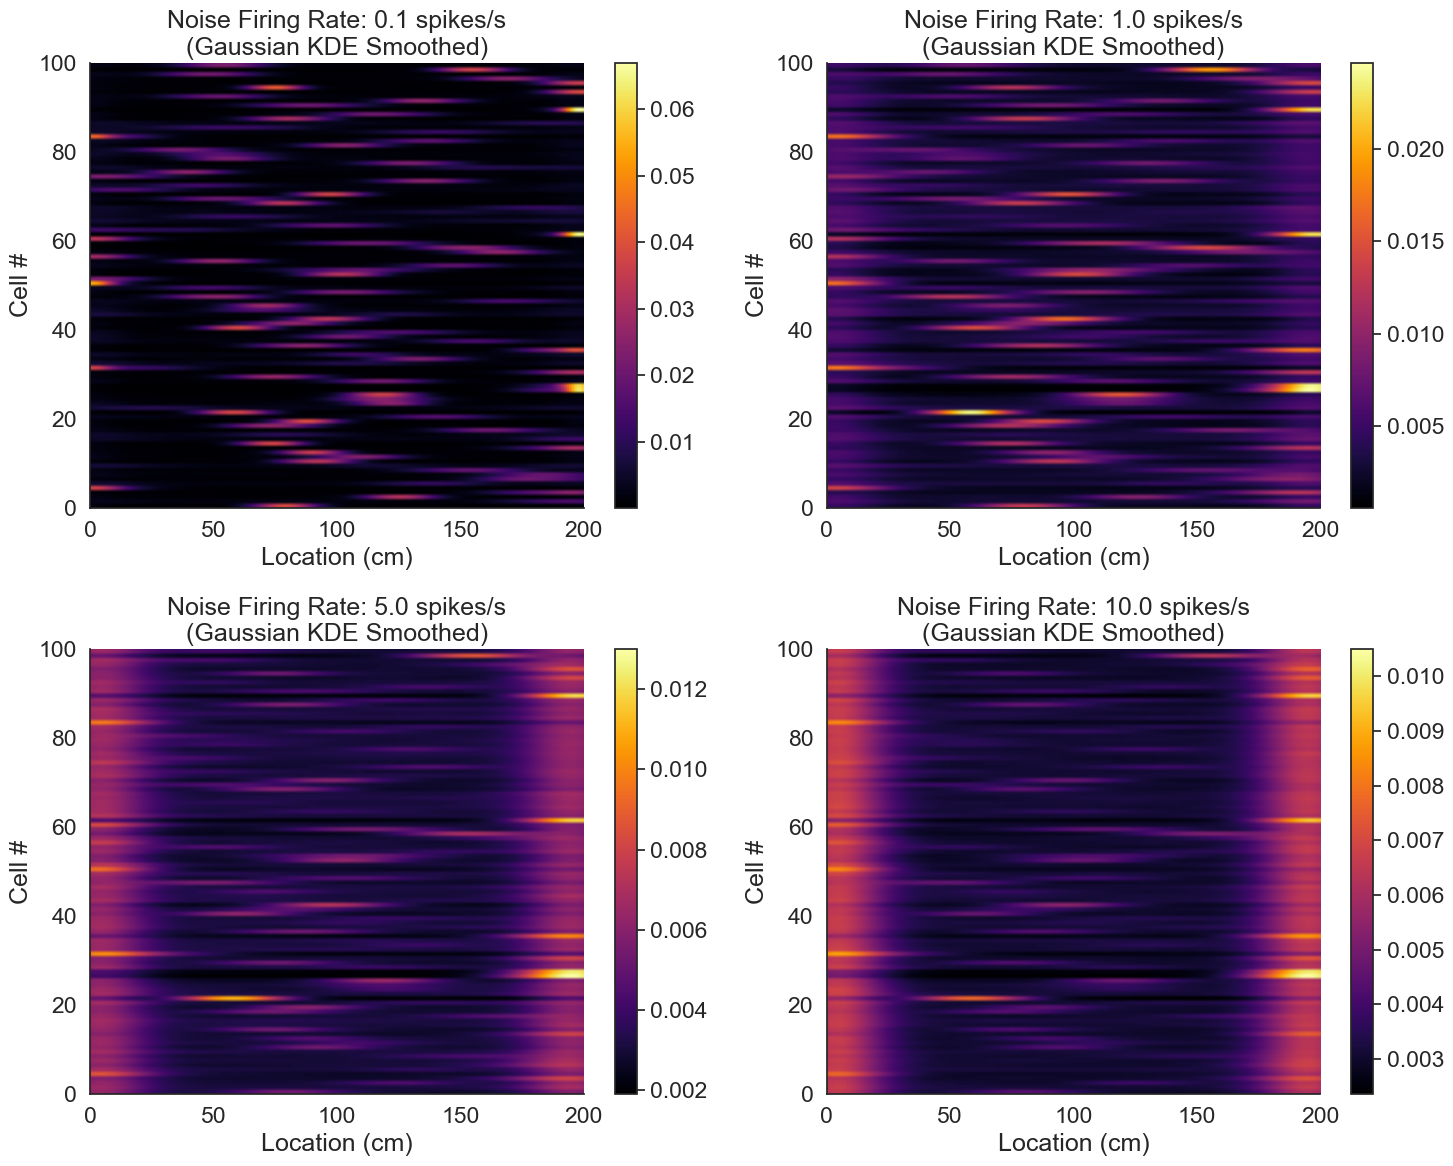

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from tqdm import tqdm

# Define noise levels to test
noise_values = [0.1, 1.0, 5.0, 10.0]

# Fixed spatial range: 0-200 cm (1 cm resolution)
space_range = np.linspace(0, 200, 201)  # 201 points for 0-200 in steps of 1

# Initialize a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for j, noise_firing_rate in enumerate(noise_values):
    # Simulate spikes for this noise level
    spikes = []
    t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
    x_sampling = np.floor(np.interp(t_sampling, t, x))

    for i in tqdm(range(n_cells)):
        inst_rate = true_firing_rate_maps[i, x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate / sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)

    # Convert spike times to positions
    spike_positions = [np.interp(spike_times, t, x) for spike_times in spikes]

    
    # Create firing rate maps using the gaussian smoother from scipy
    smoothed_firing_rates = []
    for pos in spike_positions:
        pos = np.ravel(pos)
        # Apply gaussian kde to the spike positions
        kde = gaussian_kde(pos, bw_method=0.2)
        smoothed_rate = kde(space_range)
        smoothed_firing_rates.append(smoothed_rate)

    # Stack into a matrix for plotting
    smoothed_firing_rates = np.vstack(smoothed_firing_rates)

    # Plot
    im = axes[j].imshow(smoothed_firing_rates, cmap='inferno', extent=[0, 200, 0, n_cells], aspect='auto')
    axes[j].set_title(f"Noise Firing Rate: {noise_firing_rate} spikes/s\n(Gaussian KDE Smoothed)")
    axes[j].set_xlabel('Location (cm)')
    axes[j].set_ylabel('Cell #')
    fig.colorbar(im, ax=axes[j])

plt.tight_layout()
plt.show()

**Comment Exercise 1C**
Having applied a gaussian smoother, the firing rate streaks look more like smears. No individual bins can be seen as the bins have size 1 (1 cm) have been smoothened resulting in the smears. Increasing the noise makes it harder to detect firing rates in general, especially towards the center of the plots (~100 cm). The edges of the track (0 cm and 200 cm) get an increasingly hint with increasing noise, but here the firing rate traces become more pronounced with increasing nosie as well, perhaps because the smoother incorporates noise into actual signal (?).

### **Exercise 1D**

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:18<00:00,  1.27it/s]


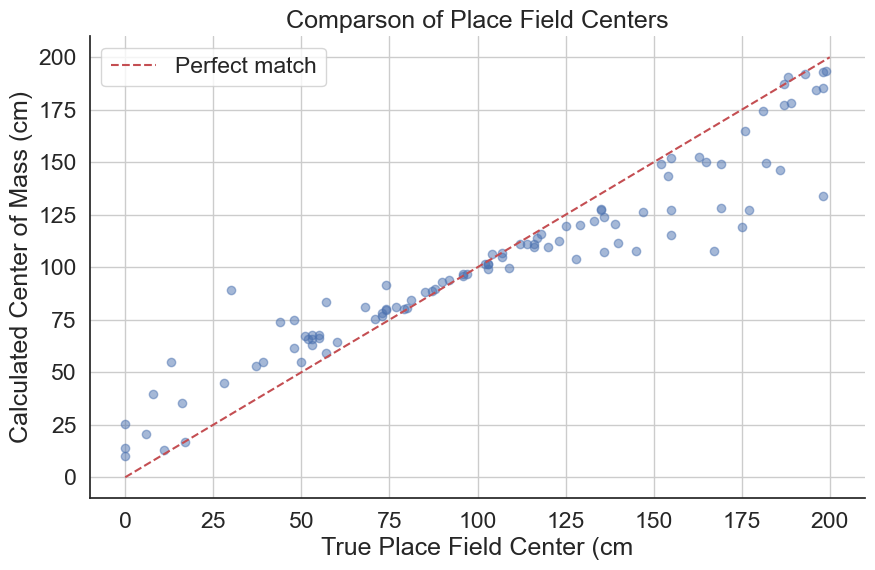

In [21]:
# Calcluate center of amss for each neuron by taking the mean of all spike positions for each neuron

# Choose a specific noise level (e.g., 0.1)
noise_firing_rate = 0.1

# Simulate spikes for this noise level
spikes = []
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))

for i in tqdm(range(n_cells)):
    inst_rate = true_firing_rate_maps[i, x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate / sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

# Convert spike times to positions
spike_positions = [np.interp(spike_times, t, x) for spike_times in spikes]

# Compute center of mass for each neuron
place_field_centers = []
for pos in spike_positions:
    N_spikes = len(pos)
    sum_L = np.sum(pos)
    center = (1 / N_spikes) * sum_L
    place_field_centers.append(center)

place_field_centers = np.array(place_field_centers)


# determine true placef ield center 
true_place_field_centers = []
for i in range(n_cells):
    # find bin of max firing rate per neuron
    max_fr_bin = np.argmax(true_firing_rate_maps[i, :])
    true_center = space_range[max_fr_bin] #convert bin into location
    true_place_field_centers.append(true_center)

true_place_field_centers = np.array(true_place_field_centers)

# Plot the comparison
plt.figure(figsize=(10, 6))
plt.scatter(true_place_field_centers, place_field_centers, alpha=0.5)
plt.plot([0, 200], [0, 200], 'r--', label='Perfect match')  # Diagonal line
plt.xlabel('True Place Field Center (cm')
plt.ylabel('Calculated Center of Mass (cm)')
plt.title('Comparson of Place Field Centers')
plt.legend()
plt.grid(True)
plt.show()

**Comment Exercise 1D**
I have created new spikes, as the old variable spike_position was calculated in a nested for-loop that iterated over varying noise level and neuron. i have used the positions/locations of each spike to calculate the sum of the location of all spikes perneuron and divided that by the total numebr of spikes, thereby following the given equation for the center of mass of a place field. for the true place field centers, i have found the max firing rate values from the true_firing_rate_maps data, defined in the lecture code, and took the bin index from that max firing rate value, and converted that into location as the true center of the true place fields. (i guess this answer the "which variables are we talking about?"question...answer: max firing rate values per neuron and its corresponding location bin to get to the true place field center per neuron)
The figure shows that the calculated center of mass values are similar to the true place field center if they dots lie on the red dotted line (where calculation=true pfc). there are quite some that lie on or near the line, but also some that are quite off, suggesting that the calculation used is not incredibly accurate.